# Data Import
After cleaning and transforming the raw data with dbt, we can import the data directly from PostgreSQL.

In [35]:
import pandas as pd
from sqlalchemy import create_engine

In [62]:
# 1. Setup local Postgres connection string
DATABASE_URL = "postgresql://Kabir@localhost:5432/resilience_gap"

# 2. Create the SQLAlchemy engine
engine = create_engine(DATABASE_URL)

# 3. Load the mart table straight into a Pandas DataFrame
query = "SELECT * FROM dbt_dev.mart_merge"
ess_survey = pd.read_sql(query, con=engine)

print(f"Data loaded. Shape: {ess_survey.shape}")

Data loaded. Shape: (14329, 83)


# Investigating Data
Reorder columns after merge (easier to do with pandas than with SQL or dbt), then check missingness proportions. 

In [63]:
# Review columns in data
ess_survey.columns

Index(['ess11_region_code', 'nuts1', 'nuts1_gdp_euro_2022',
       'nuts1_gdp_pct_eu_avg_2022', 'nuts1_unemployment_rate_pct_2022',
       'nuts1_net_migration_2022', 'nuts1_pop_density_2022',
       'nuts1_pop_growth_rate_2022', 'delta_gdp_pct_eu_avg_5yr',
       'delta_unemployment_pct_5yr', 'delta_net_migration_2yr',
       'delta_pop_growth_rate_5yr', 'respondent_id', 'country_code',
       'nuts_level', 'nuts_region', 'design_wt', 'post_stratification_wt',
       'pop_size_wt', 'analysis_wt', 'news_pol_ca_mins_daily',
       'internet_use_mins_daily', 'polintr', 'personal_say_govt',
       'personal_influence_politics', 'post_online_pol_last_yr', 'ppltrst',
       'pplfair', 'pplhlp', 'trstprl', 'trstlgl', 'trst_pols',
       'trst_pol_parties', 'trt_euro_parl', 'trstun', 'vote_yn', 'vote_fr',
       'vote_de1', 'vote_de2', 'vote_gr', 'vote_it', 'vote_pl', 'vote_es',
       'vote_se', 'left_right_alignment', 'eu_role', 'sat_life', 'sat_economy',
       'sat_gov', 'sat_demo', 'sat_

In [65]:
# 1. Define logical column order categories

structural_cols = [
    'respondent_id', 'country_code', 'nuts_level', 'nuts_region', 
    'ess11_region_code', 'nuts1'
]

weight_cols = [
    'design_wt', 'post_stratification_wt', 'pop_size_wt', 'analysis_wt'
]

macro_levels_2022 = [
    'nuts1_gdp_euro_2022', 'nuts1_gdp_pct_eu_avg_2022', 'nuts1_unemployment_rate_pct_2022',
    'nuts1_net_migration_2022', 'nuts1_pop_density_2022', 'nuts1_pop_growth_rate_2022'
]

macro_deltas = [
    'delta_gdp_pct_eu_avg_5yr', 'delta_unemployment_pct_5yr', 
    'delta_net_migration_2yr', 'delta_pop_growth_rate_5yr'
]

trust_and_politics = [
    'left_right_alignment', 'polintr', 'personal_say_govt', 'personal_influence_politics', 
    'post_online_pol_last_yr', 'news_pol_ca_mins_daily', 'internet_use_mins_daily',
    'ppltrst', 'pplfair', 'pplhlp', 'trstprl', 'trstlgl', 'trst_pols', 
    'trst_pol_parties', 'trt_euro_parl', 'trstun'
]

social_mobility_and_economic = [
    'hh_income_decile', 'hh_income_comfort', 'educ_attainment', 'educ_years_completed',
    'unemp_last_5_years', 'unemp_over_3_mos_ever', 'unemp_over_12_mos_ever', 
    'skills_course_last_year', 'govt_role_income_inequality'
]

voting_blocks = [
    'vote_yn', 'vote_fr', 'vote_de1', 'vote_de2', 'vote_gr', 'vote_it', 'vote_pl', 
    'vote_es', 'vote_se'
]

attitudes_and_satisfaction = [
    'sat_life', 'sat_economy', 'sat_gov', 'sat_demo', 'sat_educ', 'sat_health', 'happy',
    'allow_diverse_immigrants', 'allow_same_ethnic_immigrants', 'allow_poorer_immigrants',
    'immigration_impact_economy', 'immigration_impact_culture', 'immigrants_impact_country',
    'eu_role', 'country_attachment', 'eur_attachment'
]

demographic_controls = [
    'gender', 'age', 'agegroup', 'citizen', 'personal_discrim_against', 
    'identify_ethnic_majority', 'religious', 'how_religious',
    'imp_treat_ppl_equally', 'imp_understand_diff_ppl', 'imp_govt_strength',
    'educ_attainment_father', 'educ_attainment_mother'
]

# 2. Combine all blocks into a single ordered list
logical_column_order = (
    structural_cols + weight_cols + macro_levels_2022 + macro_deltas + 
    trust_and_politics + social_mobility_and_economic + voting_blocks + 
    attitudes_and_satisfaction + demographic_controls
)

# 3. Reorders the dataframe columns in place
ess_survey = ess_survey[logical_column_order]

print(f"Shape: {ess_survey.shape}") # Check no columns forgotten. Previous shape was (14329, 83)

Shape: (14329, 83)


In [66]:
# 1. Calculate the percentage of missing values per country for every column
missing_report = (
    ess_survey.groupby('country_code')
    .apply(lambda x: (x.isnull().sum() / len(x)) * 100)
    # Drop the grouping column from the axis to avoid redundancy
    .drop(columns=['country_code'], errors='ignore')
)

# 2. Transpose the results so columns are rows, making it incredibly easy to scroll through
missing_report_pivoted = missing_report.T

# 3. Display the full matrix (preventing pandas from clipping rows)
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(missing_report_pivoted.round(2))

country_code                       DE     ES     FR     GR     IT     PL  \
respondent_id                     0.0    0.0    0.0    0.0    0.0    0.0   
nuts_level                        0.0    0.0    0.0    0.0    0.0    0.0   
nuts_region                       0.0    0.0    0.0    0.0    0.0    0.0   
ess11_region_code                 0.0    0.0    0.0    0.0    0.0    0.0   
nuts1                             0.0    0.0    0.0    0.0    0.0    0.0   
design_wt                         0.0    0.0    0.0    0.0    0.0    0.0   
post_stratification_wt            0.0    0.0    0.0    0.0    0.0    0.0   
pop_size_wt                       0.0    0.0    0.0    0.0    0.0    0.0   
analysis_wt                       0.0    0.0    0.0    0.0    0.0    0.0   
nuts1_gdp_euro_2022               0.0    0.0    0.0    0.0    0.0    0.0   
nuts1_gdp_pct_eu_avg_2022         0.0    0.0    0.0    0.0    0.0    0.0   
nuts1_unemployment_rate_pct_2022  0.0    0.0    0.0    0.0    0.0    0.0   
nuts1_net_mi

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [60]:
# Set theme
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11, 
    'axes.labelsize': 12, 
    'axes.titlesize': 13,
    'legend.title_fontsize': 11
})

/var/folders/8x/_6srvv510170nx5xz7b75jp00000gn/T/ipykernel_76483/1211992305.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


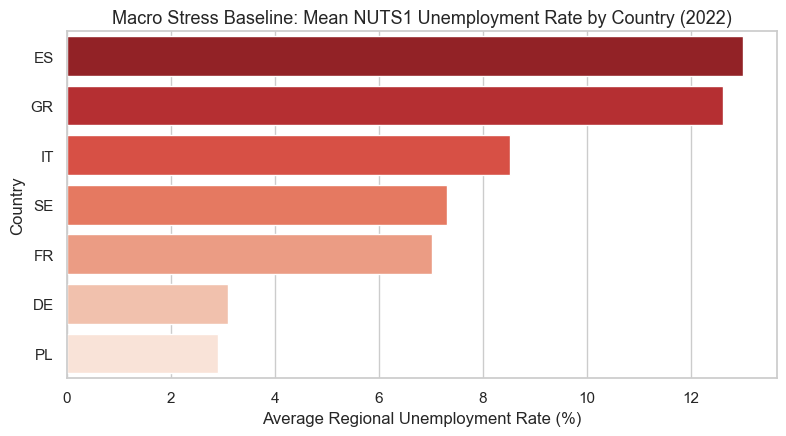

In [ ]:
# Unemployment
fig, ax = plt.subplots(figsize=(8, 4.5))

unemp_by_country = (
    ess_survey.groupby('country_code')['nuts1_unemployment_rate_pct_2022']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

sns.barplot(
    data=unemp_by_country, 
    x='nuts1_unemployment_rate_pct_2022', 
    y='country_code', 
    palette='Reds_r',
    ax=ax
)
ax.set_title('Macro Stress Baseline: Mean NUTS1 Unemployment Rate by Country (2022)')
ax.set_xlabel('Average Regional Unemployment Rate (%)')
ax.set_ylabel('Country')
plt.tight_layout()
#plt.savefig('01_macro_unemployment_by_country.png', dpi=300)



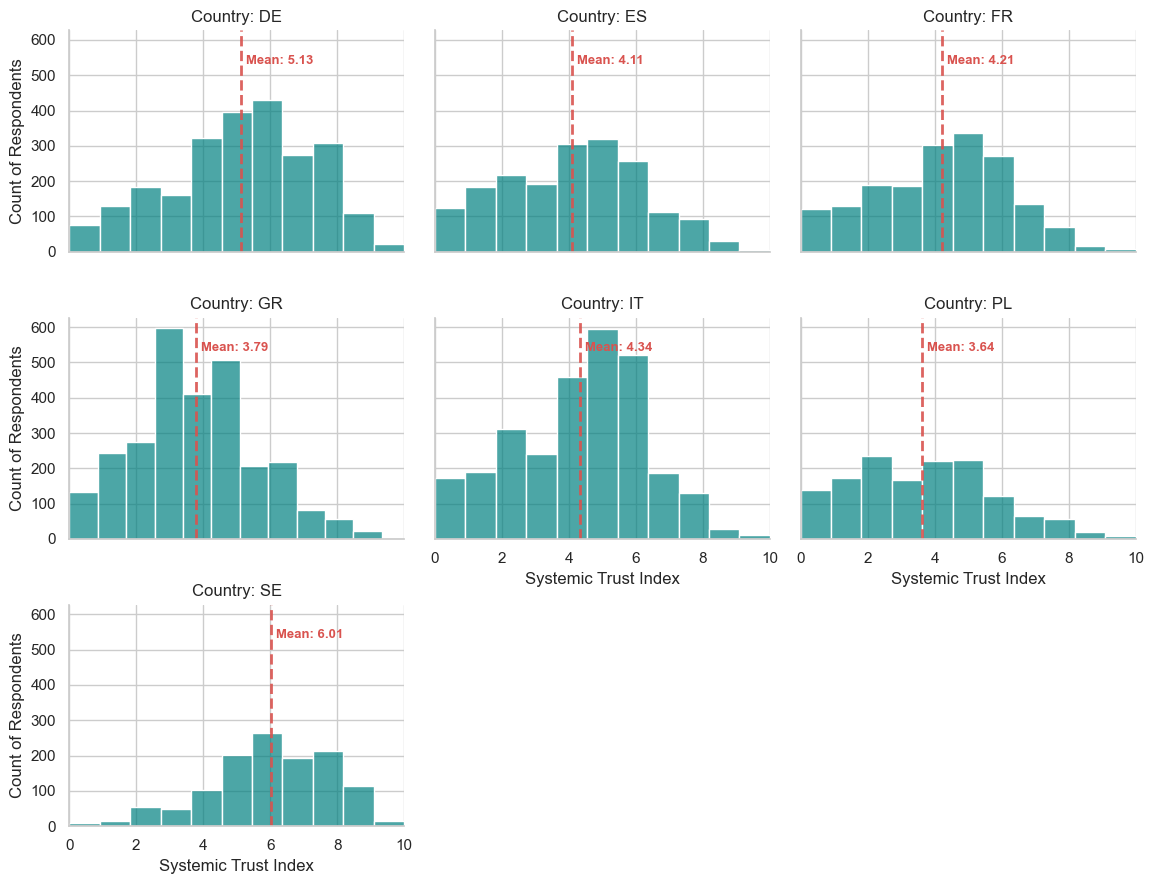

In [ ]:
# Set professional theme parameters
sns.set_theme(style="whitegrid")

trust_vectors = ['trstprl', 'trstlgl', 'trst_pol_parties']

# 1. Create a clean working copy of the dataset containing only essential columns
clean_trust_df = ess_survey[['country_code', 'nuts1'] + trust_vectors].copy()

# 2. Convert ESS missing codes to NaN
for col in trust_vectors:
    clean_trust_df[col] = pd.to_numeric(clean_trust_df[col], errors='coerce')
    clean_trust_df.loc[clean_trust_df[col] > 10, col] = np.nan

# 3. Calculate the index mean and drop rows where all three are missing
clean_trust_df['systemic_trust_index'] = clean_trust_df[trust_vectors].mean(axis=1)
clean_trust_df = clean_trust_df.dropna(subset=['systemic_trust_index'])

# 4. Define a custom function to calculate and draw the mean line per facet
def draw_mean_line(data, **kwargs):
    mean_val = data['systemic_trust_index'].mean()
    ax = plt.gca()
    
    # Draw the dashed vertical line
    ax.axvline(mean_val, color='#d9534f', linestyle='--', linewidth=2, alpha=0.9)
    
    # Annotate the numerical mean value
    # ax.get_xaxis_transform() locks the Y coordinate to a relative scale (0 = bottom, 1 = top)
    # This ensures the text always sits perfectly at 85% height regardless of respondent counts
    ax.text(
        x=mean_val + 0.15, 
        y=0.85, 
        s=f'Mean: {mean_val:.2f}', 
        transform=ax.get_xaxis_transform(), 
        color='#d9534f', 
        weight='bold', 
        fontsize=9.5
    )

# 5. Initialize the FacetGrid (This will dynamically accommodate your 7 countries)
g = sns.FacetGrid(
    clean_trust_df, 
    col="country_code", 
    col_wrap=3, 
    height=3, 
    aspect=1.3
)

# 6. Map the baseline histograms onto the grid
g.map_dataframe(
    sns.histplot, 
    x="systemic_trust_index", 
    bins=11, 
    color="teal", 
    alpha=0.7
)

# 7. Map our custom mean-line function on top of the histograms
g.map_dataframe(draw_mean_line)

# 8. Polish layout and axes boundaries
g.set_axis_labels("Systemic Trust Index", "Count of Respondents")
g.set_titles(col_template="Country: {col_name}")

for ax in g.axes.flat:
    ax.set_xlim(0, 10)
    ax.set_xticks([0, 2, 4, 6, 8, 10])

plt.tight_layout()
#plt.savefig('02_systemic_trust_index_faceted_with_mean.png', dpi=300)

/var/folders/8x/_6srvv510170nx5xz7b75jp00000gn/T/ipykernel_76483/2821129616.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


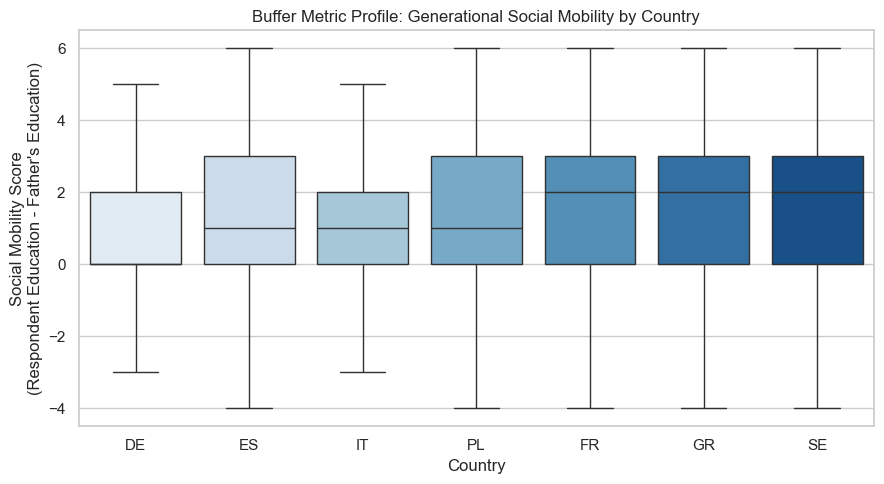

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set professional theme parameters
sns.set_theme(style="whitegrid")

# 1. Create a working copy
clean_mobility_df = ess_survey[['country_code', 'educ_attainment', 'educ_attainment_father']].copy()

# 2. Convert raw columns to numeric, catching string artifacts
clean_mobility_df['educ_attainment'] = pd.to_numeric(clean_mobility_df['educ_attainment'], errors='coerce')
clean_mobility_df['educ_attainment_father'] = pd.to_numeric(clean_mobility_df['educ_attainment_father'], errors='coerce')

# 3. Suppress the ESS placeholder codes (77, 88, 99, 7777, etc.) to NaN
clean_mobility_df.loc[clean_mobility_df['educ_attainment'] > 10, 'educ_attainment'] = np.nan
clean_mobility_df.loc[clean_mobility_df['educ_attainment_father'] > 10, 'educ_attainment_father'] = np.nan

# 4. Calculate the clean social mobility score (Pandas will naturally result in NaN if either side is missing)
clean_mobility_df['social_mobility_score'] = (
    clean_mobility_df['educ_attainment'] - clean_mobility_df['educ_attainment_father']
)

# 5. Drop the NaN rows so our groupby median sorting doesn't hit errors
clean_mobility_df = clean_mobility_df.dropna(subset=['social_mobility_score'])

# 6. Sort countries sequentially by median mobility score
country_mobility_order = (
    clean_mobility_df.groupby('country_code')['social_mobility_score']
    .median()
    .sort_values()
    .index
)

# 7. Render the clean boxplot
fig, ax = plt.subplots(figsize=(9, 5))

sns.boxplot(
    data=clean_mobility_df, 
    x='country_code', 
    y='social_mobility_score', 
    order=country_mobility_order, 
    palette='Blues',
    ax=ax,
    showfliers=False # Optional: hides extreme statistical outliers to make the main boxes look larger and crisper
)

ax.set_title('Buffer Metric Profile: Generational Social Mobility by Country')
ax.set_xlabel('Country')
ax.set_ylabel("Social Mobility Score\n(Respondent Education - Father's Education)")

plt.tight_layout()
#plt.savefig('03_social_mobility_by_country.png', dpi=300)

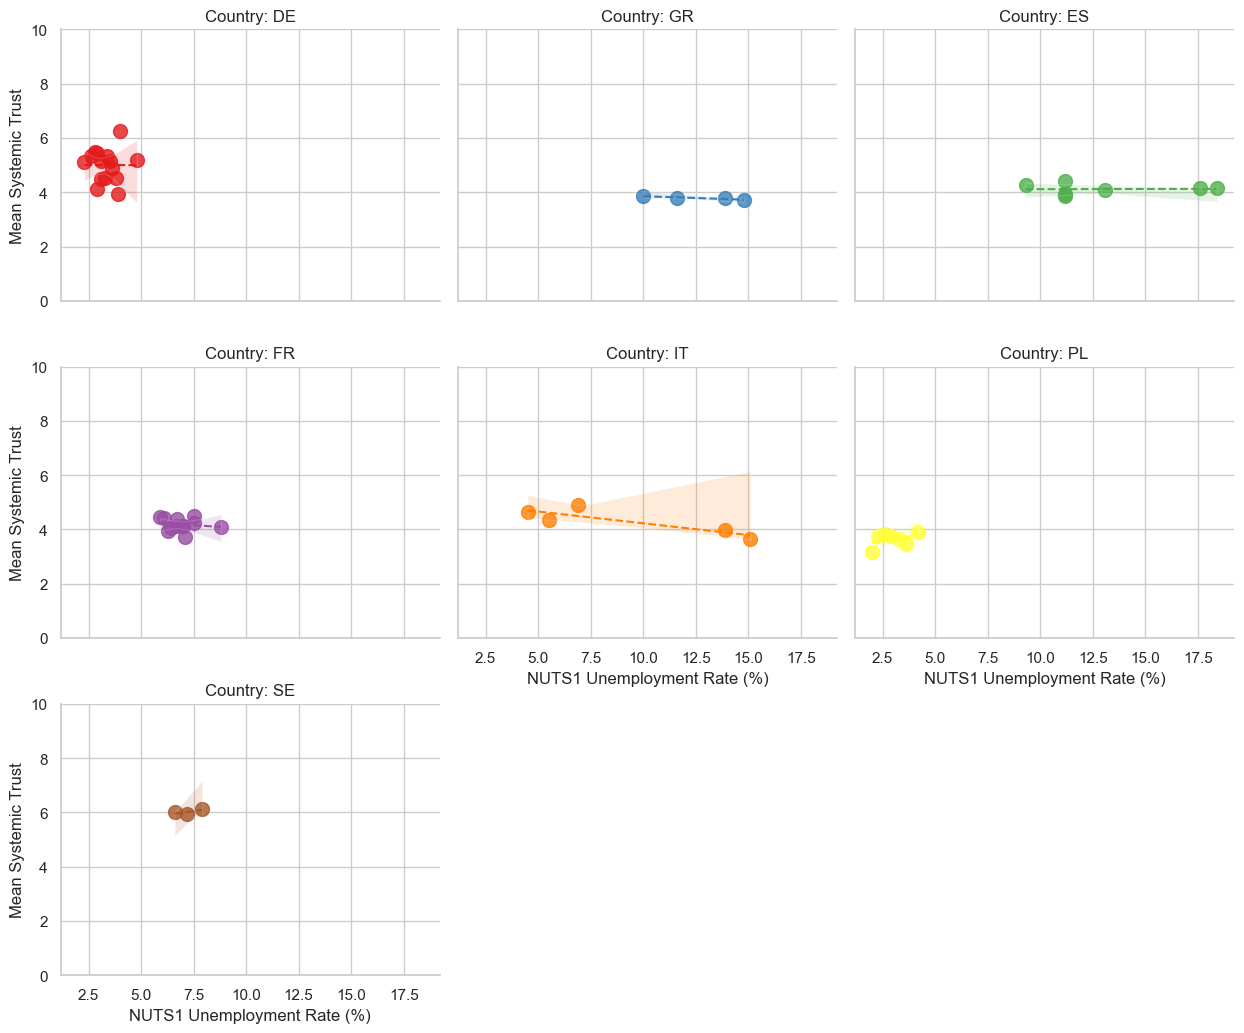

In [ ]:
# Set professional theme parameters
sns.set_theme(style="whitegrid")

trust_vectors = ['trstprl', 'trstlgl', 'trst_pol_parties']

# 1. Create a clean working copy
clean_df = ess_survey.loc[
    :, ['country_code', 'nuts1', 'nuts1_unemployment_rate_pct_2022'] + trust_vectors
].copy()

# 2. Convert trust columns to numeric and strip out ESS placeholder codes
for col in trust_vectors:
    clean_df[col] = pd.to_numeric(clean_df[col], errors='coerce')
    clean_df.loc[clean_df[col] > 10, col] = np.nan

# 3. Calculate clean individual trust index and drop missing records
clean_df['systemic_trust_index'] = clean_df[trust_vectors].mean(axis=1)
clean_df = clean_df.dropna(subset=['systemic_trust_index', 'nuts1_unemployment_rate_pct_2022'])

# 4. Aggregate individuals up to NUTS1 regional portfolios
regional_portfolios = clean_df.groupby(['nuts1', 'country_code']).agg({
    'nuts1_unemployment_rate_pct_2022': 'first',
    'systemic_trust_index': 'mean'
}).reset_index()

# 5. Use lmplot to facet by country and automatically draw trendlines
# col_wrap=3 organizes the 6 countries into a clean 2x3 grid matrix
g = sns.lmplot(
    data=regional_portfolios,
    x='nuts1_unemployment_rate_pct_2022',
    y='systemic_trust_index',
    col='country_code',
    col_wrap=3,
    hue='country_code',
    palette='Set1',
    height=3.5,
    aspect=1.2,
    scatter_kws={'s': 100, 'alpha': 0.8},
    line_kws={'linestyle': '--', 'linewidth': 1.5}
)

# 6. Polish layouts, titles, and label parameters across all subplots
g.set_axis_labels("NUTS1 Unemployment Rate (%)", "Mean Systemic Trust")
g.set_titles(col_template="Country: {col_name}")

# Enforce consistent formatting across axes limits
for ax in g.axes.flat:
    ax.set_ylim(0, 10) # Enforce strict 0-10 trust scale bounds
    # Dynamically expand X-limits slightly per plot to let points breathe, 
    # but keep them clean and readable.

plt.tight_layout()
#plt.savefig('04_regional_unemployment_vs_trust_faceted.png', dpi=300)